<a href="https://colab.research.google.com/github/LevTsaturyan/ML_2025_autumn/blob/main/ML3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
dat = pd.read_csv('chipotle.tsv', sep ='\t')
dat.tail(10)

,order_id,quantity,item_name,choice_description,item_price
4612,1831,1,Carnitas Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Rice,...",$9.25
4613,1831,1,Chips,NaN,$2.15
4614,1831,1,Bottled Water,NaN,$1.50
4615,1832,1,Chicken Soft Tacos,"[Fresh Tomato Salsa, [Rice, Cheese, Sour Cream]]",$8.75
4616,1832,1,Chips and Guacamole,NaN,$4.45
4617,1833,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Sour ...",$11.75
4618,1833,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Sour Cream, Cheese...",$11.75
4619,1834,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Pinto...",$11.25
4620,1834,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Lettu...",$8.75
4621,1834,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Pinto...",$8.75


In [ ]:
#Сколько заказов попало в выборку?
orders_count = dat['order_id'].nunique()
print(f"Всего заказов: {orders_count}")



#Сколько уникальных категорий товара было куплено? (item_name)
item_count = dat.groupby('item_name')['order_id'].count()
print(f'Куплено: {item_count}')

Всего заказов: 1834
Куплено: item_name
6 Pack Soft Drink                         54
Barbacoa Bowl                             66
Barbacoa Burrito                          91
Barbacoa Crispy Tacos                     11
Barbacoa Salad Bowl                       10
Barbacoa Soft Tacos                       25
Bottled Water                            162
Bowl                                       2
Burrito                                    6
Canned Soda                              104
Canned Soft Drink                        301
Carnitas Bowl                             68
Carnitas Burrito                          59
Carnitas Crispy Tacos                      7
Carnitas Salad                             1
Carnitas Salad Bowl                        6
Carnitas Soft Tacos                       40
Chicken Bowl                             726
Chicken Burrito                          553
Chicken Crispy Tacos                      47
Chicken Salad                              9
Chicken Salad Bo

In [ ]:
#Есть ли в данных пропуски? В каких колонках?
nulls = dat.isnull().sum()
print('Кол-во пропусков:', nulls)
# Получаем 1246 пропусков в колонке с описанием


#Заполните пропуски пустой строкой для строковых колонок и нулём для числовых.
for column in dat.columns:
    if dat[column].dtype == 'object':
        dat[column] = dat[column].fillna('')
    else:
        dat[column] = dat[column].fillna(0)
dat

Кол-во пропусков: order_id              0
quantity              0
item_name             0
choice_description    0
item_price            0
date                  0
dtype: int64


,order_id,quantity,item_name,choice_description,item_price,date
0,1,1,Chips and Fresh Tomato Salsa,,$2.39,2018-01-19
1,1,1,Izze,[Clementine],$3.39,2018-01-19
2,1,1,Nantucket Nectar,[Apple],$3.39,2018-01-19
3,1,1,Chips and Tomatillo-Green Chili Salsa,,$2.39,2018-01-19
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98,2018-01-07
...,...,...,...,...,...,...
4617,1833,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Sour ...",$11.75,2018-01-08
4618,1833,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Sour Cream, Cheese...",$11.75,2018-01-08
4619,1834,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Pinto...",$11.25,2018-01-19
4620,1834,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Lettu...",$8.75,2018-01-19


In [ ]:
#4
dat['item_price'] = dat['item_price'].str.replace('$', '').apply(float)
print(dat['item_price'].dtype)

float64


In [ ]:
dat.describe()


,order_id,quantity,item_price
count,4622.000000,4622.000000,4622.000000
mean,927.254868,1.075725,7.464336
std,528.890796,0.410186,4.245557
min,1.000000,1.000000,1.090000
25%,477.250000,1.000000,3.390000
50%,926.000000,1.000000,8.750000
75%,1393.000000,1.000000,9.250000
max,1834.000000,15.000000,44.250000


In [ ]:
dat = dat.drop('item_price', axis=1)

In [ ]:
 #Какие 5 товаров были самыми дешёвыми и самыми дорогими? (по item_name)
dat_unique = dat.drop_duplicates('item_name').copy()
dat_unique.loc[:, 'total_price'] = dat_unique['quantity'] * dat_unique['item_price']
dat_sorted = dat_unique.sort_values('total_price')
cheapest = dat_sorted.head(5)[['item_name', 'total_price']]
most_expensive = dat_sorted.tail(5)[['item_name', 'total_price']]
print(cheapest)
print(most_expensive)


                                 item_name  total_price
34                           Bottled Water         1.09
263                      Canned Soft Drink         1.25
6                            Side of Chips         1.69
40                                   Chips         2.15
3    Chips and Tomatillo-Green Chili Salsa         2.39
                item_name  total_price
1229  Barbacoa Salad Bowl        11.89
1132  Carnitas Salad Bowl        11.89
4            Chicken Bowl        33.96
281      Steak Salad Bowl        47.56
445                  Bowl        66.60


In [ ]:
dat[(dat['item_name'] == 'Chicken Bowl') & (dat['quantity'] > 1)].shape[0]

33

In [ ]:
#Какой средний чек у заказа? Сколько в среднем товаров покупают?
dat['total'] = dat['quantity'] * dat['item_price']
order_stats = dat.groupby('order_id').agg(total_price=('total','sum'), total_quantity=('quantity','sum'))
order_stats['total_price'].mean(), order_stats['total_quantity'].mean()


(np.float64(21.39423118865867), np.float64(2.711014176663032))

In [ ]:
# Сколько заказов содержали ровно 1 товар?
(order_stats['total_quantity'] == 1).sum()

np.int64(56)

In [ ]:
dat['category'] = dat['item_name'].str.split().str[-1]
dat['category'].value_counts().idxmax()
#Какая самая популярная категория товара?

'Bowl'

In [ ]:
burritos = dat[dat['item_name'].str.contains('Burrito')]
burrito_types = burritos['item_name'].unique()
most_common = burritos['item_name'].value_counts().idxmax()
burrito_prices = burritos.groupby('item_name').agg(total_price=('item_price','mean'))
most_expensive = burrito_prices['total_price'].idxmax()
burrito_types, most_common, most_expensive
#Какие виды Burrito существуют? Какой из них чаще всего покупают? Какой из них самый дорогой?

(array(['Steak Burrito', 'Chicken Burrito', 'Barbacoa Burrito',
        'Carnitas Burrito', 'Veggie Burrito', 'Burrito'], dtype=object),
 'Chicken Burrito',
 'Steak Burrito')

In [ ]:
dat['total'] = dat['quantity'] * dat['item_price']
order_totals = dat.groupby('order_id')['total'].sum()
dat = dat.merge(order_totals.rename('order_total'), on='order_id')
(dat['total'] > 0.4 * dat['order_total']).groupby(dat['order_id']).any().sum()
# В каком количестве заказов есть товар, который стоит более 40% от суммы всего чека?

np.int64(1637)

In [ ]:
mask = dat['item_name'].str.contains('Diet Coke', case=False)
if mask.any():
    old_total = (dat.loc[mask,'quantity'] * dat.loc[mask,'item_price']).sum()
    dat.loc[mask,'item_price'] = 1.35
    new_total = (dat.loc[mask,'quantity'] * dat.loc[mask,'item_price']).sum()
    increase_pct = (new_total - old_total)/old_total*100
else:
    increase_pct = 0
increase_pct
#12

0

In [ ]:
matrix = [
    ['Убийственный класс', 'комедия', 'боевик'],
    ['Стальной Алхимик: Братство', 'боевик', ''],
    ['Саики Кусуо', 'комедия', ''],
    ['Твоя апрельская ложь', 'романтика', 'драма'],
    ['Нитидзё', 'комедия', ''],
    ['Steins;Gate', 'фантастика', 'триллер'],
    ['Хоримия', 'романтика', ''],
    ['Моя геройская академия', 'комедия', 'боевик'],
    ['Fate/Zero', 'триллер', 'боевик'],
    ['Корзинка фруктов', 'романтика', ''],
    ['Плутон', 'триллер', 'боевик'],
    ['Галактика Татами', 'комедия', 'фантастика'],
    ['Атака титанов', 'боевик', 'триллер'],
    ['Ковбой Бибоп', 'фантастика', 'боевик'],
    ['Шова Генроку Ракуго Синдзю', 'драма', '']
]

df = pd.DataFrame(matrix, columns=['index','column1','column2']).set_index('index')
df

,column1,column2
index,,
Убийственный класс,комедия,боевик
Стальной Алхимик: Братство,боевик,
Саики Кусуо,комедия,
Твоя апрельская ложь,романтика,драма
Нитидзё,комедия,
Steins;Gate,фантастика,триллер
Хоримия,романтика,
Моя геройская академия,комедия,боевик
Fate/Zero,триллер,боевик


In [ ]:
df.to_csv('matrix.csv', index=False, header=False)


Часть 2

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

In [ ]:
import datetime, random

start = datetime.datetime(2018, 1, 1)
end = datetime.datetime(2018, 1, 31)
delta_seconds = int((end - start).total_seconds())

dates = pd.DataFrame(index=dat.order_id.unique())
dates['date'] = [
    (start + datetime.timedelta(seconds=random.randint(0, delta_seconds))).strftime('%Y-%m-%d')
    for _ in range(dat.order_id.nunique())
]

dat['date'] = dat.order_id.map(dates['date'])

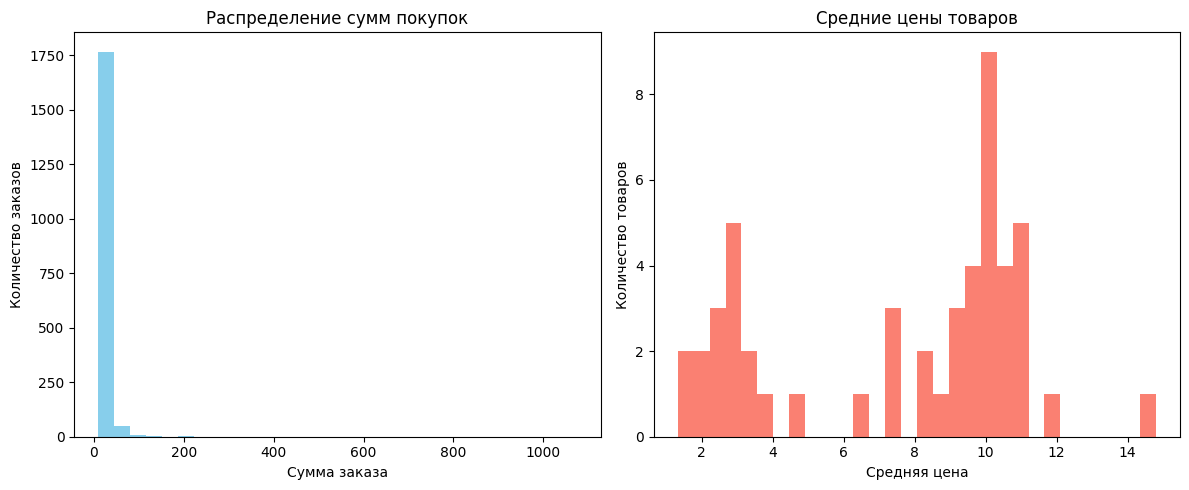

In [ ]:
#Постройте гистограмму распределения сумм покупок и гистограмму средних цен отдельных видов продуктов item_name.
order_totals = dat.groupby('order_id')['total'].sum()
item_avg_prices = dat.groupby('item_name')['item_price'].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(order_totals, bins=30, color='skyblue')
axes[0].set_title('Распределение сумм покупок')
axes[0].set_xlabel('Сумма заказа')
axes[0].set_ylabel('Количество заказов')

axes[1].hist(item_avg_prices, bins=30, color='salmon')
axes[1].set_title('Средние цены товаров')
axes[1].set_xlabel('Средняя цена')
axes[1].set_ylabel('Количество товаров')

plt.tight_layout()
plt.show()

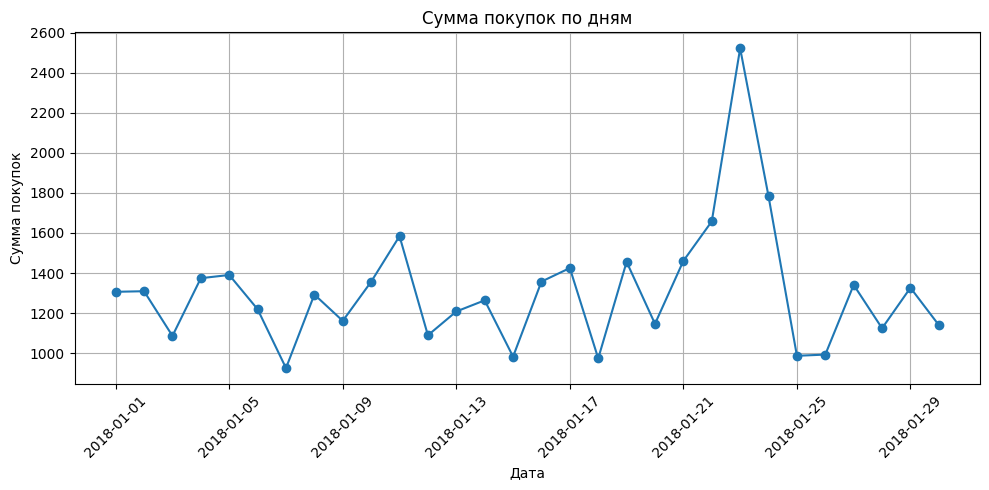

In [ ]:
dat['date'] = pd.to_datetime(dat['date'])
daily_totals = dat.groupby('date')['total'].sum()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(daily_totals.index, daily_totals.values, marker='o')
plt.title('Сумма покупок по дням')
plt.xlabel('Дата')
plt.ylabel('Сумма покупок')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


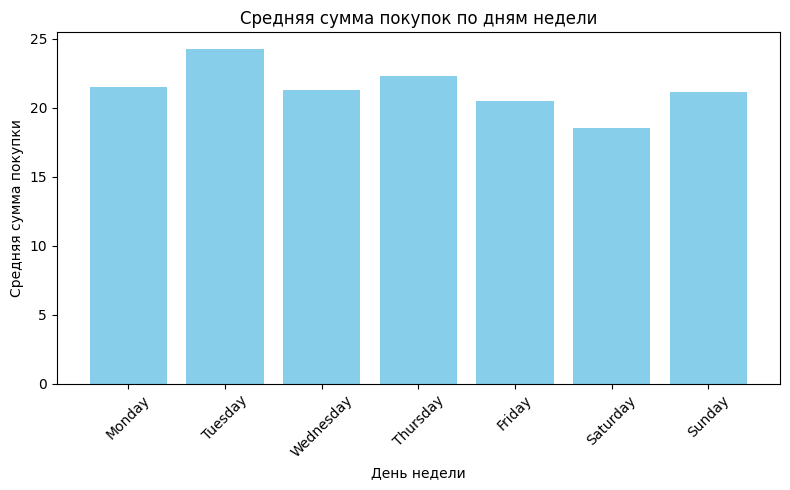

In [ ]:
dat['weekday'] = dat['date'].dt.day_name()
daily_avg = dat.groupby('weekday')['total'].sum() / dat.groupby('weekday')['order_id'].nunique()

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_avg = daily_avg.reindex(weekday_order)

plt.figure(figsize=(8,5))
plt.bar(daily_avg.index, daily_avg.values, color='skyblue')
plt.title('Средняя сумма покупок по дням недели')
plt.xlabel('День недели')
plt.ylabel('Средняя сумма покупки')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

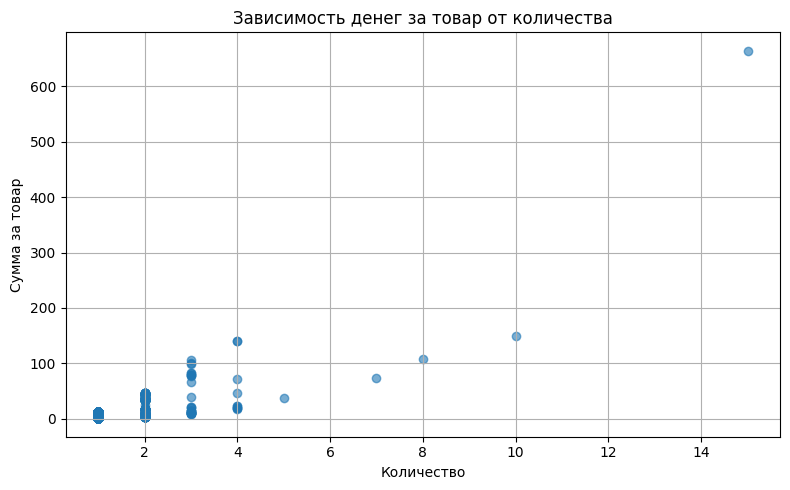

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(dat['quantity'], dat['total'], alpha=0.6)
plt.title('Зависимость денег за товар от количества')
plt.xlabel('Количество')
plt.ylabel('Сумма за товар')
plt.grid(True)
plt.tight_layout()
plt.show()
plt.savefig('scatter_plot.pdf')